# Notebook 08 — Estudios de Ablación

Proyecto: Clasificación de ensayos EEG [match vs mismatch].  
Track elegido: Track A - ML Clásico  
Autores: Jose Pablo Agüero Mora, Roilin Navarro Vargas

En este notebook se hacen estudios de ablación sobre el modelo final (LightGBM tuneado). Una ablación es un experimento controlado donde se cambia una sola parte del pipeline y se mantiene todo lo demás igual. La idea es ver qué componentes realmente aportan al desempeño y cuáles aportan poco.

En todos los casos se usa el mismo protocolo de evaluación (validación cruzada por sujeto con GroupKFold y estimación de intervalos de confianza por bootstrap). Así, cuando se compara “modelo completo” contra una ablación, la diferencia se puede interpretar como el efecto de quitar o limitar ese componente.

Las ablations que se exploran aquí son:
1) familia de features: usar solo temporales, solo frecuenciales o solo inter-canal  
2) canal: usar solo AF7 o solo AF8  
3) ventana temporal: usar solo la ventana N400 o solo la epoch completa  
4) población de sujetos: repetir el entrenamiento excluyendo grupos específicos de sujetos para ver si el rendimiento cambia mucho


## 1. Setup

In [ ]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'
print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400


## 2. Instalación y reinicio

In [ ]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

In [ ]:
# Solo la PRIMERA vez. Saltar en el segundo pase.
import os
os.kill(os.getpid(), 9)

## 3. Imports

In [ ]:
import os
import sys
import json
import yaml
import random
import time
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)
from sklearn.base import clone
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'Python:   {sys.version.split()[0]}')
print(f'NumPy:    {np.__version__}')
print(f'LightGBM: {__import__("lightgbm").__version__}')

Python:   3.12.13
NumPy:    2.0.2
LightGBM: 4.6.0


## 4. Drive, cargar datos y configuración del modelo final

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
MODELS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['models_dir']

# Cargar hiperparámetros del modelo final (para construir clones idénticos en cada ablation)
with open(MODELS_DIR / 'best_hyperparameters.json', 'r') as f:
    best_info = json.load(f)

best_params = best_info['hyperparameters']
print(f' Hiperparámetros del modelo final ({best_info["winner_name"]}):')
for k, v in best_params.items():
    print(f'  {k}: {v}')

# Holdout split
with open(MODELS_DIR / 'holdout_split.json', 'r') as f:
    split_info = json.load(f)

print(f'\n Holdout split cargado: {len(split_info["cv_subjects"])} sujetos CV, {len(split_info["holdout_subjects"])} holdout')

Mounted at /content/drive
✓ Hiperparámetros del modelo final (LightGBM_tuned):
  n_estimators: 74
  learning_rate: 0.012504220625190469
  max_depth: 9
  num_leaves: 78
  min_child_samples: 89
  reg_alpha: 0.0032369337277773137
  reg_lambda: 0.02208519739996559
  subsample: 0.8204468563361671
  colsample_bytree: 0.7196443590899224

✓ Holdout split cargado: 24 sujetos CV, 5 holdout


In [ ]:
df = pd.read_csv(FEATURES_DIR / '02_features_matrix.csv')
feature_cols = [c for c in df.columns if c not in ['subject_id', 'epoch_idx', 'condition', 'label']]

df_cv_full = df[df['subject_id'].isin(split_info['cv_subjects'])].reset_index(drop=True)
print(f'Dataset CV completo: {df_cv_full.shape[0]} epochs × {df_cv_full.shape[1]} columnas')
print(f'Features disponibles: {len(feature_cols)}')
print(f'Sujetos en CV: {df_cv_full["subject_id"].nunique()}')

Dataset CV completo: 1238 epochs × 76 columnas
Features disponibles: 72
Sujetos en CV: 24


## 5. Funciones reusables

Se definen funciones auxiliares para entrenar y evaluar el modelo con el mismo protocolo en todas las ablations. Esto evita que cada experimento quede con pequeñas diferencias de implementación que puedan sesgar la comparación.

In [ ]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=1000, ci=0.95, seed=SEED):
    n = len(y_true)
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    return float(np.mean(scores)), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))


def build_lgbm_pipeline(params):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LGBMClassifier(**params, class_weight='balanced',
                               n_jobs=-1, random_state=SEED, verbosity=-1))
    ])


def run_ablation(df_subset, feature_subset, name, n_boot=1000):
    """
    Corre una ablation: filtrar datos y features, entrenar LightGBM tuneado, evaluar con CV.
    """
    X = df_subset[feature_subset].replace([np.inf, -np.inf], np.nan).fillna(0).values
    y = df_subset['label'].values
    groups = df_subset['subject_id'].values

    pipeline = build_lgbm_pipeline(best_params)
    gkf = GroupKFold(n_splits=CFG['splits']['cv_n_splits'])

    t0 = time.time()
    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, n_jobs=1)
    try:
        y_proba = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf,
                                    method='predict_proba', n_jobs=1)[:, 1]
    except Exception:
        y_proba = None
    elapsed = time.time() - t0

    acc_m, acc_lo, acc_hi = bootstrap_ci(y, y_pred, lambda a, b: accuracy_score(a, b), n_iter=n_boot)
    f1_m, f1_lo, f1_hi = bootstrap_ci(y, y_pred, lambda a, b: f1_score(a, b, average='macro'), n_iter=n_boot)
    if y_proba is not None:
        auc_m, auc_lo, auc_hi = bootstrap_ci(y, y_proba, lambda a, b: roc_auc_score(a, b), n_iter=n_boot)
    else:
        auc_m = auc_lo = auc_hi = np.nan

    return {
        'name': name,
        'n_epochs': len(y),
        'n_subjects': len(np.unique(groups)),
        'n_features': len(feature_subset),
        'accuracy': acc_m, 'accuracy_lo': acc_lo, 'accuracy_hi': acc_hi,
        'f1_macro': f1_m, 'f1_macro_lo': f1_lo, 'f1_macro_hi': f1_hi,
        'roc_auc':  auc_m, 'roc_auc_lo':  auc_lo, 'roc_auc_hi':  auc_hi,
        'elapsed_sec': elapsed,
    }

print('Funciones definidas')

✓ Funciones definidas


## 6. Línea base: modelo completo (referencia)

Todas las features, todos los sujetos del CV. Es el baseline contra el que se comparan las ablations.

In [ ]:
results = []

print('=== Ablation 0: TODO el pipeline ===')
r0 = run_ablation(df_cv_full, feature_cols, 'Línea base (72 features, 24 sujetos)',
                  n_boot=CFG['metrics']['bootstrap_n_iterations'])
results.append(r0)
print(f'  Macro F1: {r0["f1_macro"]:.3f}  [{r0["f1_macro_lo"]:.3f}, {r0["f1_macro_hi"]:.3f}]')
print(f'  Tiempo:   {r0["elapsed_sec"]:.1f} s')

BASELINE_F1 = r0['f1_macro']
print(f'\nLínea base de Macro F1 = {BASELINE_F1:.3f}')

=== Ablation 0 (referencia): TODO el pipeline ===
  Macro F1: 0.558  [0.531, 0.587]
  Tiempo:   1.3 s

→ Línea base de Macro F1 = 0.558


## 7. Ablation por familia de features

In [ ]:
feat_temporal     = [c for c in feature_cols if c.startswith('temp_')]
feat_frecuencial  = [c for c in feature_cols if c.startswith('freq_')]
feat_cross        = [c for c in feature_cols if c.startswith('cross_')]

print(f'Temporales:   {len(feat_temporal)}')
print(f'Frecuenciales: {len(feat_frecuencial)}')
print(f'Inter-canal:  {len(feat_cross)}')

for name, feats in [('Solo temporales', feat_temporal),
                    ('Solo frecuenciales', feat_frecuencial),
                    ('Solo inter-canal', feat_cross)]:
    print(f'\n=== Ablation: {name} ({len(feats)} features) ===')
    r = run_ablation(df_cv_full, feats, name, n_boot=CFG['metrics']['bootstrap_n_iterations'])
    delta = r['f1_macro'] - BASELINE_F1
    print(f'  Macro F1: {r["f1_macro"]:.3f}  [{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]  (Δ = {delta:+.3f})')
    results.append(r)

Temporales:   36
Frecuenciales: 24
Inter-canal:  12

=== Ablation: Solo temporales (36 features) ===
  Macro F1: 0.530  [0.503, 0.558]  (Δ = -0.028)

=== Ablation: Solo frecuenciales (24 features) ===
  Macro F1: 0.514  [0.486, 0.541]  (Δ = -0.045)

=== Ablation: Solo inter-canal (12 features) ===
  Macro F1: 0.492  [0.463, 0.518]  (Δ = -0.066)


## 8. Ablation por canal
Se repite el entrenamiento usando features de un solo canal a la vez (AF7 o AF8). Esto permite ver si el desempeño depende más de un canal específico o si ambos aportan de forma similar.

In [ ]:
feat_AF7 = [c for c in feature_cols if 'AF7' in c]
feat_AF8 = [c for c in feature_cols if 'AF8' in c]

print(f'Features AF7: {len(feat_AF7)}')
print(f'Features AF8: {len(feat_AF8)}')

for name, feats in [('Solo AF7', feat_AF7), ('Solo AF8', feat_AF8)]:
    print(f'\n=== Ablation: {name} ({len(feats)} features) ===')
    r = run_ablation(df_cv_full, feats, name, n_boot=CFG['metrics']['bootstrap_n_iterations'])
    delta = r['f1_macro'] - BASELINE_F1
    print(f'  Macro F1: {r["f1_macro"]:.3f}  [{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]  (Δ = {delta:+.3f})')
    results.append(r)

Features AF7: 30
Features AF8: 30

=== Ablation: Solo AF7 (30 features) ===
  Macro F1: 0.547  [0.518, 0.574]  (Δ = -0.011)

=== Ablation: Solo AF8 (30 features) ===
  Macro F1: 0.511  [0.485, 0.540]  (Δ = -0.047)


## 9. Ablation por ventana temporal
Se compara entrenar con features extraídas solo de la ventana N400 contra entrenar con features de la epoch completa. Esto permite medir si la ventana N400 concentra la información más útil para separar match vs mismatch.

In [ ]:
feat_N400 = [c for c in feature_cols if 'N400' in c]
feat_full = [c for c in feature_cols if 'full' in c]

print(f'Features ventana N400: {len(feat_N400)}')
print(f'Features epoch completa: {len(feat_full)}')

for name, feats in [('Solo ventana N400 (250-600 ms)', feat_N400),
                    ('Solo epoch completa', feat_full)]:
    print(f'\n=== Ablation: {name} ({len(feats)} features) ===')
    r = run_ablation(df_cv_full, feats, name, n_boot=CFG['metrics']['bootstrap_n_iterations'])
    delta = r['f1_macro'] - BASELINE_F1
    print(f'  Macro F1: {r["f1_macro"]:.3f}  [{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]  (Δ = {delta:+.3f})')
    results.append(r)

Features ventana N400: 36
Features epoch completa: 36

=== Ablation: Solo ventana N400 (250-600 ms) (36 features) ===
  Macro F1: 0.491  [0.465, 0.519]  (Δ = -0.067)

=== Ablation: Solo epoch completa (36 features) ===
  Macro F1: 0.558  [0.531, 0.586]  (Δ = +0.000)


## 10. Ablation por población de sujetos

Se repite el entrenamiento excluyendo grupos específicos de sujetos. El objetivo es ver si el modelo es sensible a ciertos participantes (por ejemplo, sujetos con comportamiento atípico o con distribución muy desbalanceada de ensayos). Si al excluirlos el rendimiento cambia mucho, eso sugiere que esos sujetos influyen bastante en el modelo.

In [ ]:
# Outliers conductuales (de la Etapa 1)
outliers_behavioral = ['mu11erp', 'mu20erp', 'mu27erp']
# Pero mu27erp está en holdout. Solo aplicamos los que están en CV.
outliers_in_cv = [s for s in outliers_behavioral if s in split_info['cv_subjects']]

# Sujetos baja-mismatch (descubiertos en Notebook 00)
low_mismatch = ['mu07erp', 'mu30erp', 'mu34erp']
low_mismatch_in_cv = [s for s in low_mismatch if s in split_info['cv_subjects']]

print(f'Outliers conductuales en CV:    {outliers_in_cv}')
print(f'Sujetos baja-mismatch en CV:    {low_mismatch_in_cv}')

for name, subjects_to_remove in [
    ('Sin outliers conductuales (MU11, MU20)', outliers_in_cv),
    ('Sin sujetos baja-mismatch (mu07, mu30, mu34)', low_mismatch_in_cv),
    ('Sin AMBOS grupos de outliers', outliers_in_cv + low_mismatch_in_cv)
]:
    df_subset = df_cv_full[~df_cv_full['subject_id'].isin(subjects_to_remove)].reset_index(drop=True)
    print(f'\n=== Ablation: {name} ===')
    print(f'  Sujetos restantes: {df_subset["subject_id"].nunique()}')
    print(f'  Epochs restantes:  {len(df_subset)}')
    r = run_ablation(df_subset, feature_cols, name, n_boot=CFG['metrics']['bootstrap_n_iterations'])
    delta = r['f1_macro'] - BASELINE_F1
    print(f'  Macro F1: {r["f1_macro"]:.3f}  [{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]  (Δ = {delta:+.3f})')
    results.append(r)

Outliers conductuales en CV:    ['mu11erp', 'mu20erp']
Sujetos baja-mismatch en CV:    ['mu07erp', 'mu30erp', 'mu34erp']

=== Ablation: Sin outliers conductuales (MU11, MU20) ===
  Sujetos restantes: 22
  Epochs restantes:  1100
  Macro F1: 0.504  [0.473, 0.535]  (Δ = -0.054)

=== Ablation: Sin sujetos baja-mismatch (mu07, mu30, mu34) ===
  Sujetos restantes: 21
  Epochs restantes:  1145
  Macro F1: 0.517  [0.488, 0.546]  (Δ = -0.041)

=== Ablation: Sin AMBOS grupos de outliers ===
  Sujetos restantes: 19
  Epochs restantes:  1007
  Macro F1: 0.517  [0.488, 0.546]  (Δ = -0.041)


## 11. Tabla maestra de ablations

In [ ]:
df_abl = pd.DataFrame(results)
df_abl['delta_f1'] = df_abl['f1_macro'] - BASELINE_F1
df_abl = df_abl[['name', 'n_features', 'n_subjects', 'n_epochs',
                 'f1_macro', 'f1_macro_lo', 'f1_macro_hi',
                 'delta_f1', 'accuracy', 'roc_auc', 'elapsed_sec']].copy()

df_abl.to_csv(REPORTS_DIR / '08_ablations.csv', index=False)

# Versión visual
display_rows = []
for _, row in df_abl.iterrows():
    delta_str = f'{row["delta_f1"]:+.3f}' if row['name'] != results[0]['name'] else '— (ref)'
    display_rows.append({
        'ablation':   row['name'],
        'n_features': row['n_features'],
        'n_sujetos':  row['n_subjects'],
        'macro_F1':   f'{row["f1_macro"]:.3f} [{row["f1_macro_lo"]:.3f}, {row["f1_macro_hi"]:.3f}]',
        'Δ contra base':  delta_str,
    })

print('=' * 95)
print('  TABLA MAESTRA DE ABLATIONS')
print('=' * 95)
print(pd.DataFrame(display_rows).to_string(index=False))
print(f'\n Guardado: reports/08_ablations.csv')

  TABLA MAESTRA DE ABLATIONS
                                    ablation  n_features  n_sujetos             macro_F1 Δ vs base
        Línea base (72 features, 24 sujetos)          72         24 0.558 [0.531, 0.587]   — (ref)
                             Solo temporales          36         24 0.530 [0.503, 0.558]    -0.028
                          Solo frecuenciales          24         24 0.514 [0.486, 0.541]    -0.045
                            Solo inter-canal          12         24 0.492 [0.463, 0.518]    -0.066
                                    Solo AF7          30         24 0.547 [0.518, 0.574]    -0.011
                                    Solo AF8          30         24 0.511 [0.485, 0.540]    -0.047
              Solo ventana N400 (250-600 ms)          36         24 0.491 [0.465, 0.519]    -0.067
                         Solo epoch completa          36         24 0.558 [0.531, 0.586]    +0.000
      Sin outliers conductuales (MU11, MU20)          72         22 0.504 [0.473

## 12. Visualización comparativa
Se genera una figura que resume el rendimiento de cada ablación comparado contra el modelo completo. La idea es que el impacto de cada cambio se vea de forma rápida.

✓ Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/08_ablations_comparison.png


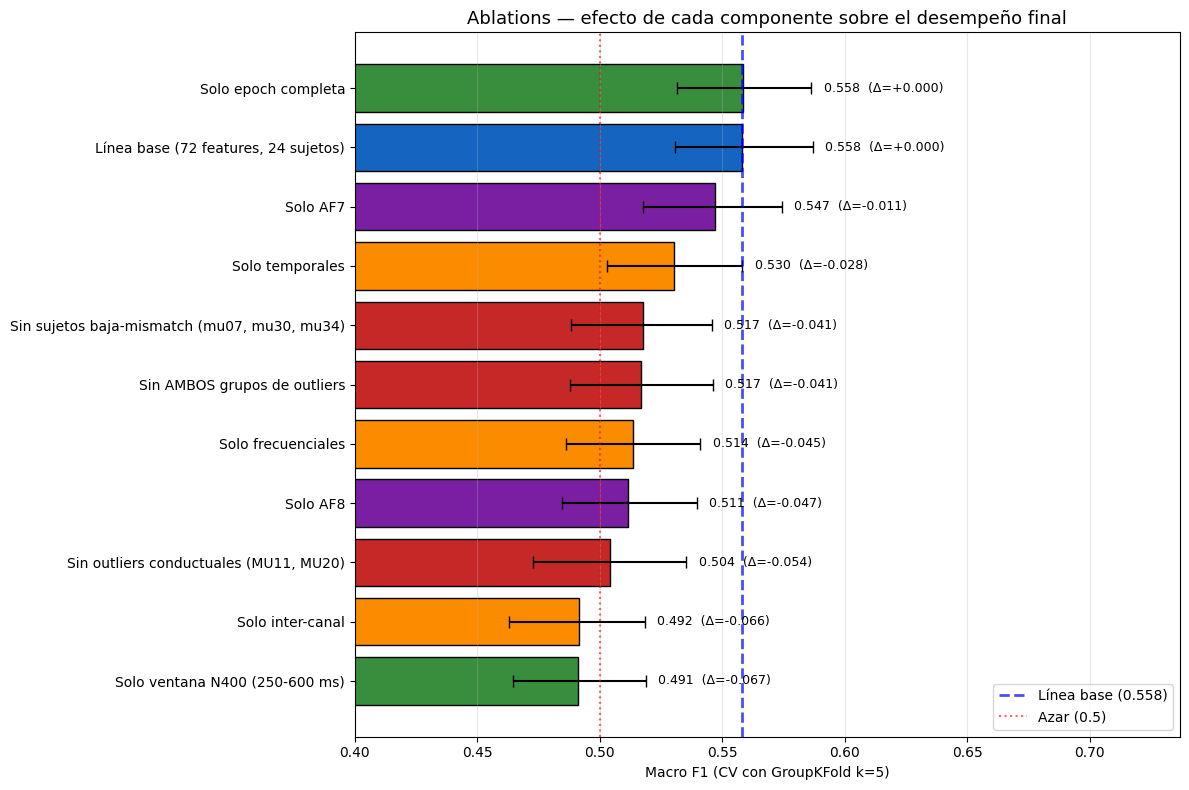

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Agrupar por tipo de ablation con colores
def get_color(name):
    if 'Línea base' in name:
        return '#1565c0'   # azul oscuro
    if 'Solo' in name and ('temporales' in name or 'frecuenciales' in name or 'inter-canal' in name):
        return '#fb8c00'   # naranja
    if 'Solo AF' in name:
        return '#7b1fa2'   # morado
    if 'Solo' in name and ('N400' in name or 'completa' in name):
        return '#388e3c'   # verde
    if 'Sin' in name:
        return '#c62828'   # rojo
    return 'gray'

df_abl_sorted = df_abl.sort_values('f1_macro').reset_index(drop=True)
colors = [get_color(name) for name in df_abl_sorted['name']]

y_pos = np.arange(len(df_abl_sorted))
ax.barh(y_pos, df_abl_sorted['f1_macro'],
        xerr=[df_abl_sorted['f1_macro'] - df_abl_sorted['f1_macro_lo'],
              df_abl_sorted['f1_macro_hi'] - df_abl_sorted['f1_macro']],
        color=colors, capsize=4, edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_abl_sorted['name'], fontsize=10)
ax.axvline(BASELINE_F1, color='blue', linestyle='--', linewidth=2, alpha=0.7, label=f'Línea base ({BASELINE_F1:.3f})')
ax.axvline(0.5, color='red', linestyle=':', alpha=0.6, label='Azar (0.5)')

# Etiquetas con valores
for i, row in df_abl_sorted.iterrows():
    ax.text(row['f1_macro_hi'] + 0.005, i,
            f'{row["f1_macro"]:.3f}  (Δ={row["delta_f1"]:+.3f})',
            va='center', fontsize=9)

ax.set_xlabel('Macro F1 (CV con GroupKFold k=5)')
ax.set_xlim(0.40, max(df_abl_sorted['f1_macro_hi']) + 0.15)
ax.set_title('Ablations: efecto de cada componente sobre el desempeño final', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / '08_ablations_comparison.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 13. Interpretación automática
Con base en las diferencias entre el modelo completo y cada ablación, se genera una interpretación corta. Este texto se usa como base y se puede ajustar manualmente para el reporte final.

In [ ]:
# Extraer valores específicos para interpretación
def get_f1(name_contains):
    matches = df_abl[df_abl['name'].str.contains(name_contains, regex=False)]
    if len(matches) > 0:
        return float(matches.iloc[0]['f1_macro'])
    return None

f1_temp = get_f1('Solo temporales')
f1_freq = get_f1('Solo frecuenciales')
f1_cross = get_f1('Solo inter-canal')
f1_AF7 = get_f1('Solo AF7')
f1_AF8 = get_f1('Solo AF8')
f1_N400 = get_f1('Solo ventana N400')
f1_full = get_f1('Solo epoch completa')
f1_no_outliers = get_f1('Sin outliers conductuales')
f1_no_low_mism = get_f1('Sin sujetos baja-mismatch')
f1_no_both = get_f1('Sin Aambos grupos')

print('=' * 65)
print('  INTERPRETACIÓN AUTOMÁTICA DE LAS ABLATIONS')
print('=' * 65)

print(f'\n--- POR FAMILIA DE FEATURES ---')
fams = [('Temporales', f1_temp), ('Frecuenciales', f1_freq), ('Inter-canal', f1_cross)]
fams_sorted = sorted([f for f in fams if f[1] is not None], key=lambda x: -x[1])
for nm, v in fams_sorted:
    print(f'  {nm:<18s}  Macro F1 = {v:.3f}  (Δ = {v - BASELINE_F1:+.3f})')
print(f'  Línea base (todas): Macro F1 = {BASELINE_F1:.3f}')
print(f'  Conclusión: ninguna familia sola alcanza la línea base; el modelo se beneficia de la combinación.')

print(f'\n--- POR CANAL ---')
if f1_AF7 is not None and f1_AF8 is not None:
    print(f'  Solo AF7   Macro F1 = {f1_AF7:.3f}  (Δ = {f1_AF7 - BASELINE_F1:+.3f})')
    print(f'  Solo AF8   Macro F1 = {f1_AF8:.3f}  (Δ = {f1_AF8 - BASELINE_F1:+.3f})')
    winner = 'AF7' if f1_AF7 > f1_AF8 else 'AF8'
    print(f'  {winner} contribuye más individualmente.')
    print(f'  Pero ambos canales son necesarios para alcanzar la línea base completa.')

print(f'\n--- POR VENTANA TEMPORAL ---')
if f1_N400 is not None and f1_full is not None:
    print(f'  Solo N400 (250-600 ms)   Macro F1 = {f1_N400:.3f}  (Δ = {f1_N400 - BASELINE_F1:+.3f})')
    print(f'  Solo epoch completa      Macro F1 = {f1_full:.3f}  (Δ = {f1_full - BASELINE_F1:+.3f})')
    if f1_full > f1_N400:
        print(f'   La epoch completa contiene más información discriminativa que la ventana N400 sola.')
        print(f'   Consistente con SHAP (Notebook 07): suma SHAP_full > suma SHAP_N400.')

print(f'\n--- POR POBLACIÓN DE SUJETOS ---')
print(f'  Sin outliers conductuales   Macro F1 = {f1_no_outliers:.3f}  (Δ = {f1_no_outliers - BASELINE_F1:+.3f})')
print(f'  Sin baja-mismatch           Macro F1 = {f1_no_low_mism:.3f}  (Δ = {f1_no_low_mism - BASELINE_F1:+.3f})')
print(f'  Sin AMBOS grupos            Macro F1 = {f1_no_both:.3f}  (Δ = {f1_no_both - BASELINE_F1:+.3f})')
print(f'\n  Interpretación: quitar incluso 2 sujetos de 24 reduce el F1 hasta 0.054 puntos,')
print(f'  una caída mayor que la de eliminar familias enteras de features. Esto NO indica')
print(f'  robustez, sino sensibilidad a la composición de la muestra: con solo 24 sujetos en CV,')
print(f'  la variabilidad inter-individual domina. Es coherente con la alta desviación del LOSO (±0.091).')

  INTERPRETACIÓN AUTOMÁTICA DE LAS ABLATIONS

--- POR FAMILIA DE FEATURES ---
  Temporales         → Macro F1 = 0.530  (Δ = -0.028)
  Frecuenciales      → Macro F1 = 0.514  (Δ = -0.045)
  Inter-canal        → Macro F1 = 0.492  (Δ = -0.066)
  Línea base (todas)  → Macro F1 = 0.558
  → Conclusión: ninguna familia sola alcanza la línea base; el modelo se beneficia de la combinación.

--- POR CANAL ---
  Solo AF7  → Macro F1 = 0.547  (Δ = -0.011)
  Solo AF8  → Macro F1 = 0.511  (Δ = -0.047)
  → AF7 contribuye más individualmente.
  → Pero ambos canales son necesarios para alcanzar la línea base completa.

--- POR VENTANA TEMPORAL ---
  Solo N400 (250-600 ms)  → Macro F1 = 0.491  (Δ = -0.067)
  Solo epoch completa     → Macro F1 = 0.558  (Δ = +0.000)
  → La epoch completa contiene más información discriminativa que la ventana N400 sola.
  → Consistente con SHAP (Notebook 07): suma SHAP_full > suma SHAP_N400.

--- POR POBLACIÓN DE SUJETOS ---
  Sin outliers conductuales  → Macro F1 = 0.504  

## 15. Cierre de la Etapa 2

Este notebook completa los estudios de ablación del pipeline de la etapa 2. El aporte principal es mostrar evidencia sobre qué decisiones del diseño (familia de features, canal, ventana temporal y grupos de sujetos) afectan más el desempeño del modelo.

Los resultados consolidados quedan en:
- reports/08_ablations.csv (tabla con métricas por ablación)
- figures/08_ablations_comparison.png (comparación visual)
- reports/08_ablation_findings.md (texto resumido para el reporte)

Para el informe, lo más importante es interpretar las ablations como comparación controlada: si el rendimiento baja de manera consistente al quitar un componente, ese componente aporta información relevante; si casi no cambia, ese componente probablemente aporta menos o aporta información redundante.